
📊 Dimensiones del archivo: (8950, 18)
Columnas: ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null  

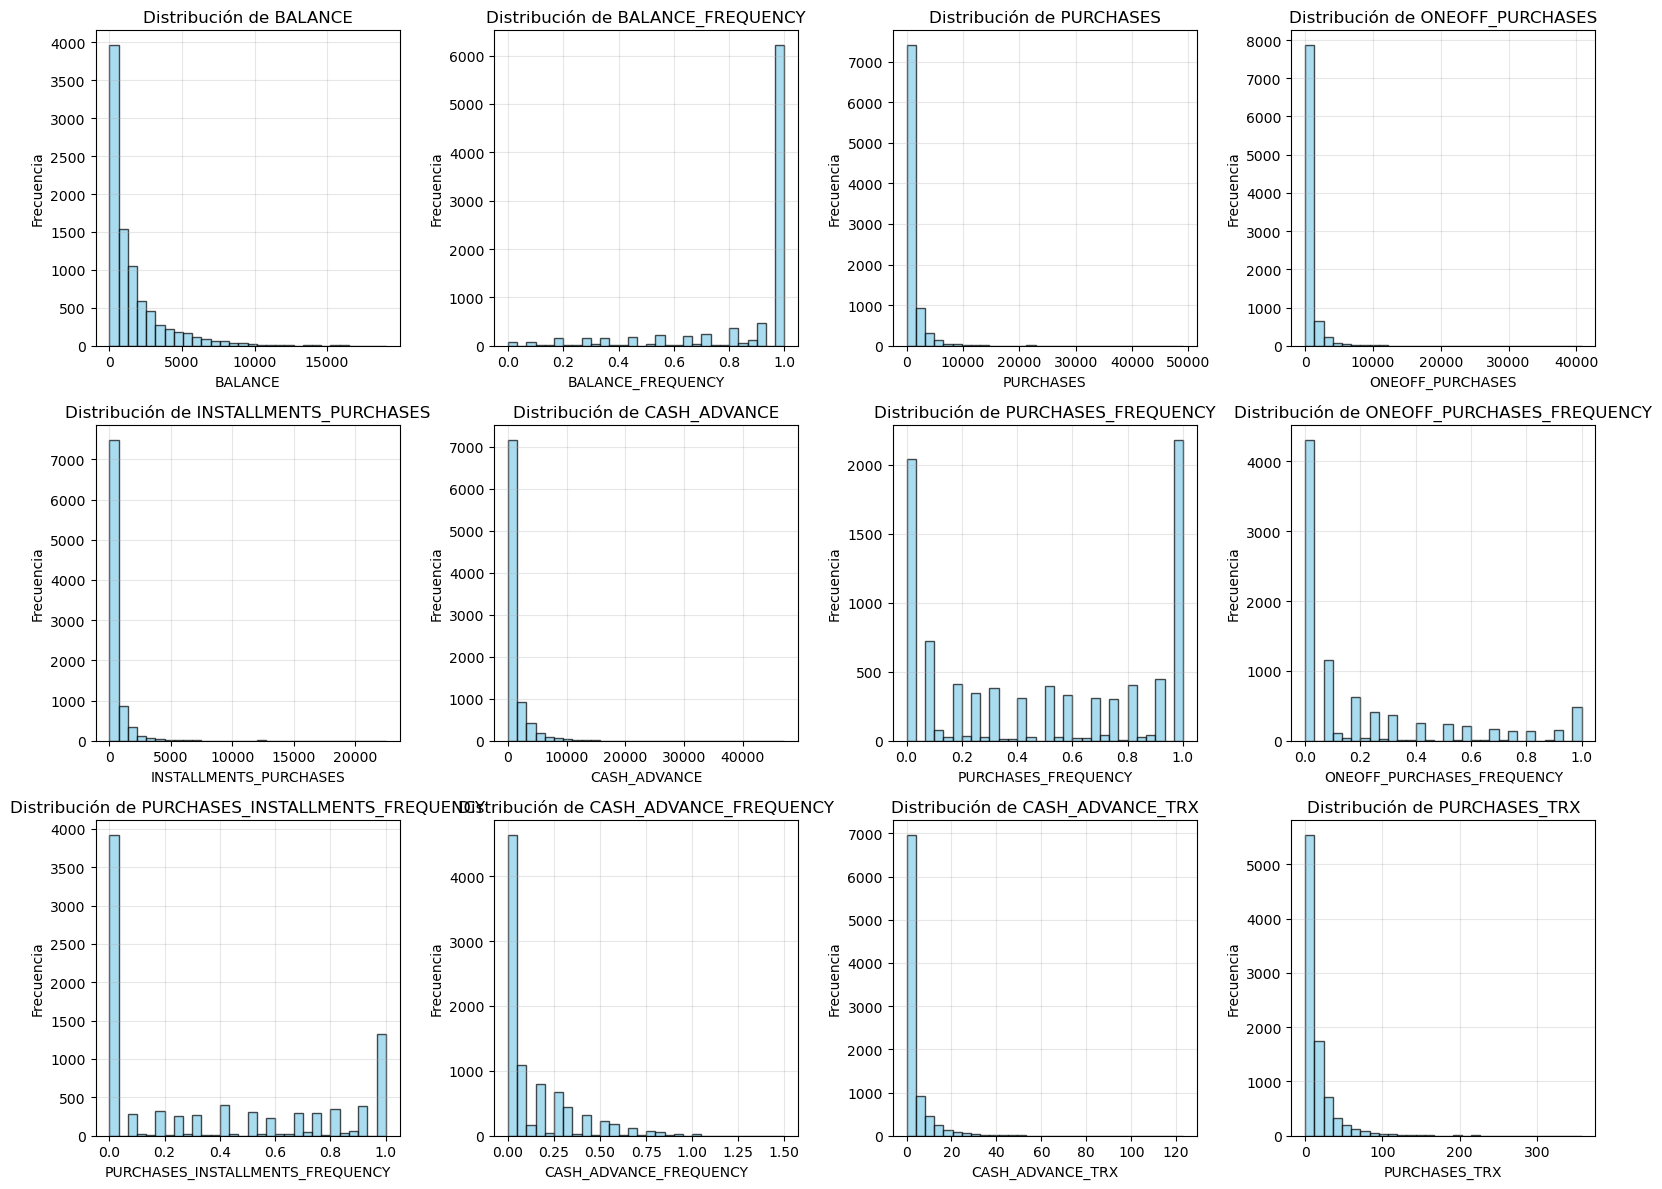

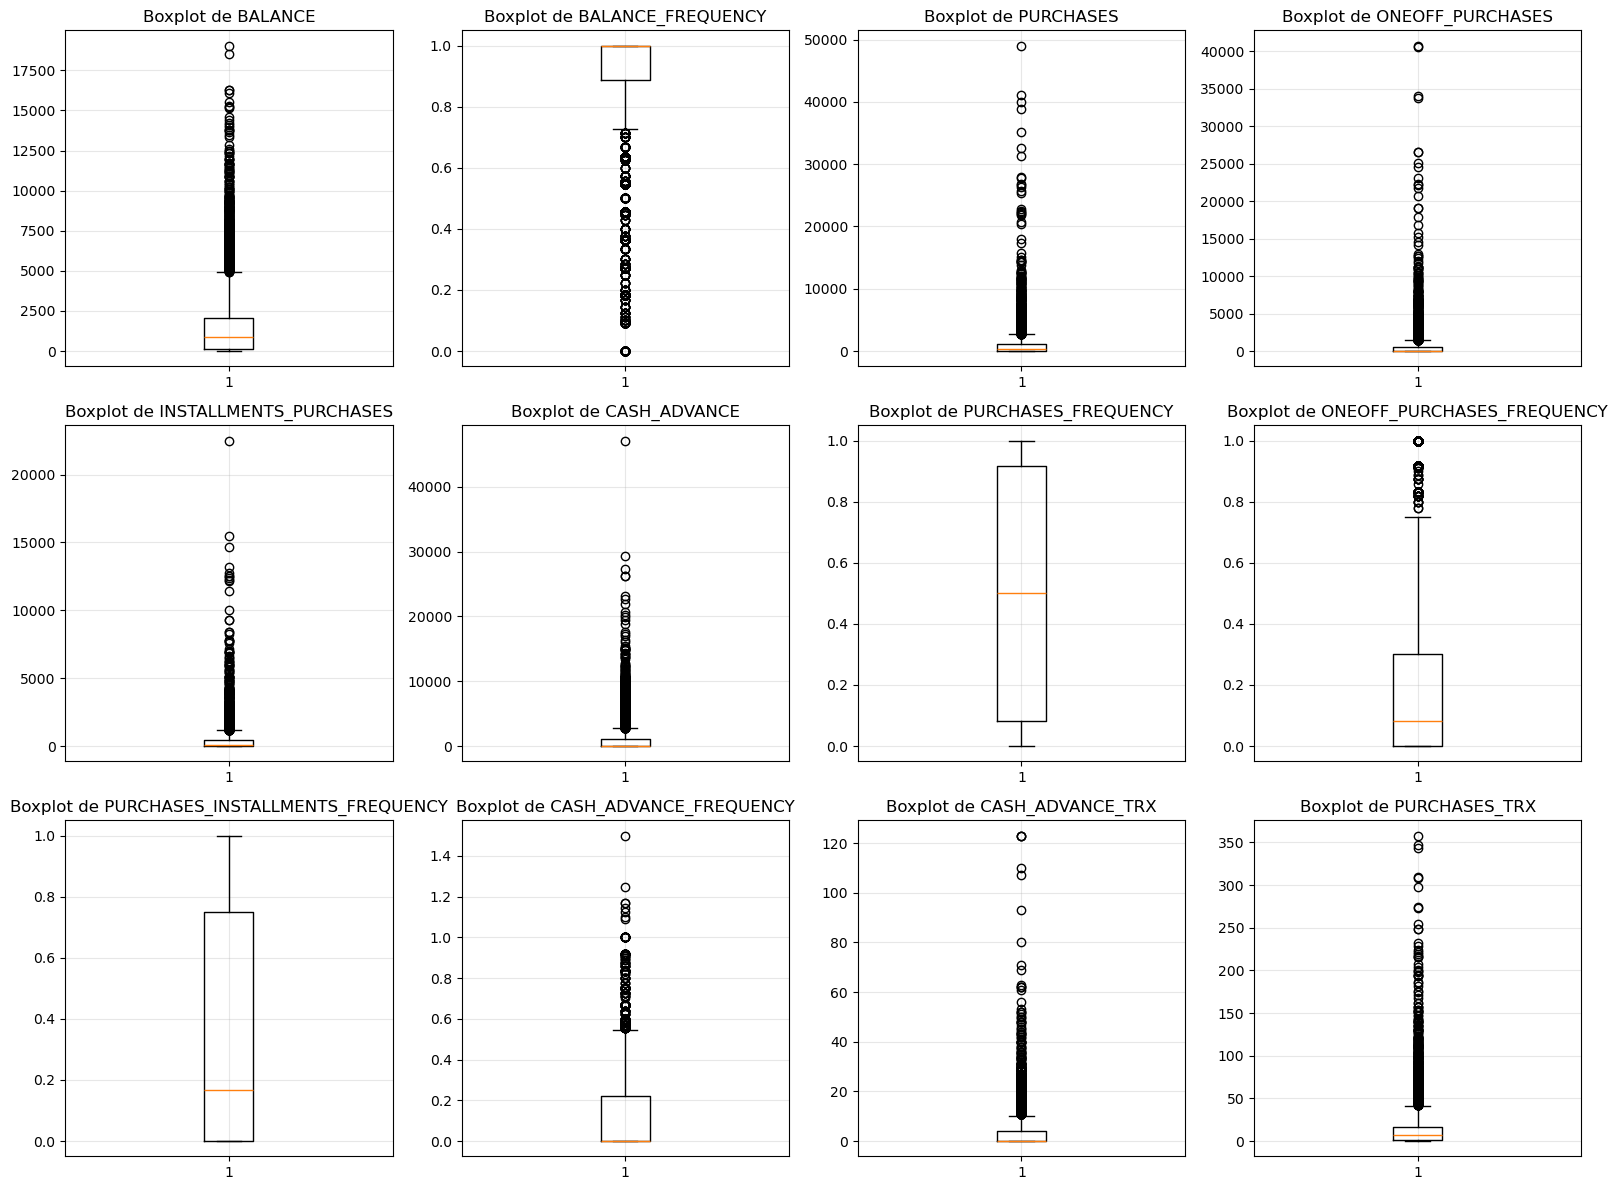


d) ESTANDARIZACIÓN DE COLUMNAS

Columnas a estandarizar: ['BALANCE', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CREDIT_LIMIT', 'MINIMUM_PAYMENTS']

🔍 Primeras 5 filas - Datos originales:
       BALANCE  ONEOFF_PURCHASES  INSTALLMENTS_PURCHASES  CREDIT_LIMIT  \
0    40.900749              0.00                    95.4        1000.0   
1  3202.467416              0.00                     0.0        7000.0   
2  2495.148862            773.17                     0.0        7500.0   
3  1666.670542           1499.00                     0.0        7500.0   
4   817.714335             16.00                     0.0        1200.0   

   MINIMUM_PAYMENTS  
0        139.509787  
1       1072.340217  
2        627.284787  
3          0.000000  
4        244.791237  

🔍 5 filas aleatorias - Datos estandarizados:
       BALANCE  ONEOFF_PURCHASES  INSTALLMENTS_PURCHASES  CREDIT_LIMIT  \
2567 -0.608946          0.491966                1.005136      3.299527   
2015  2.092193          2.461962     

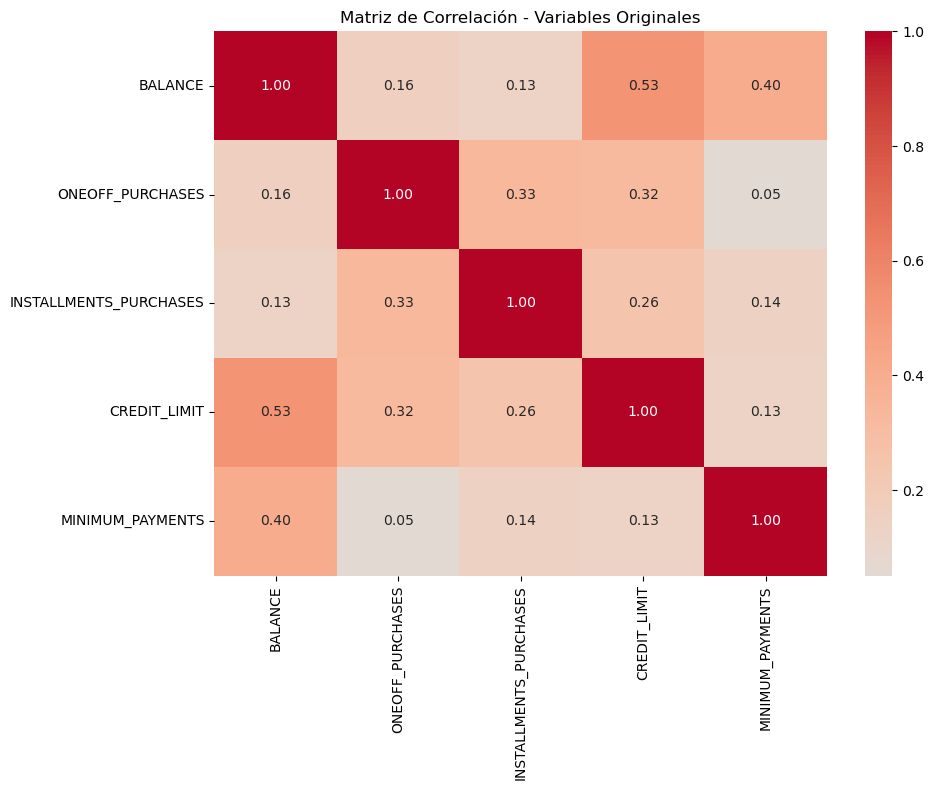

ANÁLISIS DE CLUSTERING CON K-MEANS (DATOS ESTANDARIZADOS)

📊 Verificación de estandarización:
  ONEOFF_PURCHASES: media = 0.000000, std = 1.000056
  ✅ ONEOFF_PURCHASES está correctamente estandarizado
  CREDIT_LIMIT: media = -0.000000, std = 1.000056
  ✅ CREDIT_LIMIT está correctamente estandarizado
  INSTALLMENTS_PURCHASES: media = 0.000000, std = 1.000056
  ✅ INSTALLMENTS_PURCHASES está correctamente estandarizado

✅ Datos listos para K-Means
Forma del dataset: (8950, 3)

MÉTODO DEL CODO - DETERMINACIÓN DE CLUSTERS ÓPTIMOS
✅ Gráfico del método del codo guardado como 'elbow_plot_kmeans.png'


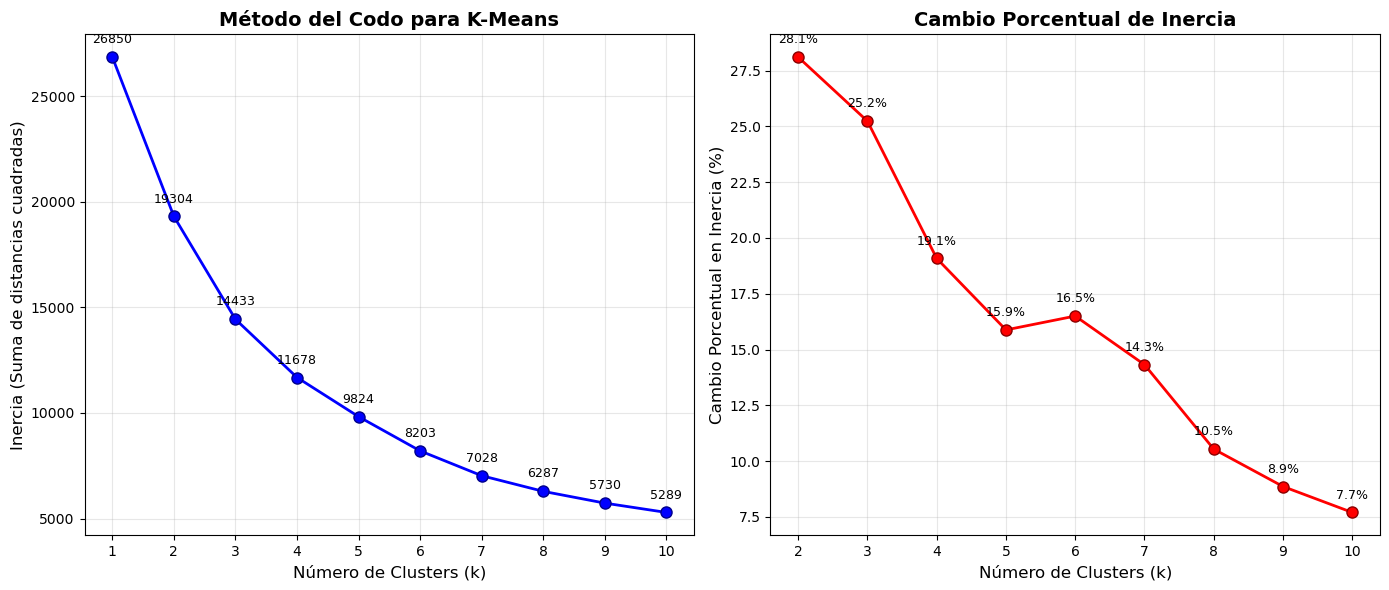


📊 Análisis del método del codo:
--------------------------------------------------
Inercia por número de clusters:
  k=1: 26850.00
  k=2: 19304.20
  k=3: 14432.93
  k=4: 11678.49
  k=5: 9823.88
  k=6: 8202.77
  k=7: 7027.96
  k=8: 6287.19
  k=9: 5729.84
  k=10: 5288.52

Cambios porcentuales:
  k=1 → k=2: 28.10% de reducción
  k=2 → k=3: 25.23% de reducción
  k=3 → k=4: 19.08% de reducción
  k=4 → k=5: 15.88% de reducción
  k=5 → k=6: 16.50% de reducción
  k=6 → k=7: 14.32% de reducción
  k=7 → k=8: 10.54% de reducción
  k=8 → k=9: 8.86% de reducción
  k=9 → k=10: 7.70% de reducción

🎯 Punto de codo identificado: k=10
   (El cambio porcentual cae por debajo de 8.1%)

APLICACIÓN DE K-MEANS

🎯 Usando k=3 clusters (según análisis del método del codo)

✅ Clustering completado con 3 clusters

B) CONTEO DE CLUSTERS ACTUALES

Distribución de clusters:
  Cluster 0: 6378 clientes (71.3%)
  Cluster 1: 112 clientes (1.3%)
  Cluster 2: 2460 clientes (27.5%)

VISUALIZACIÓN DE CLUSTERS


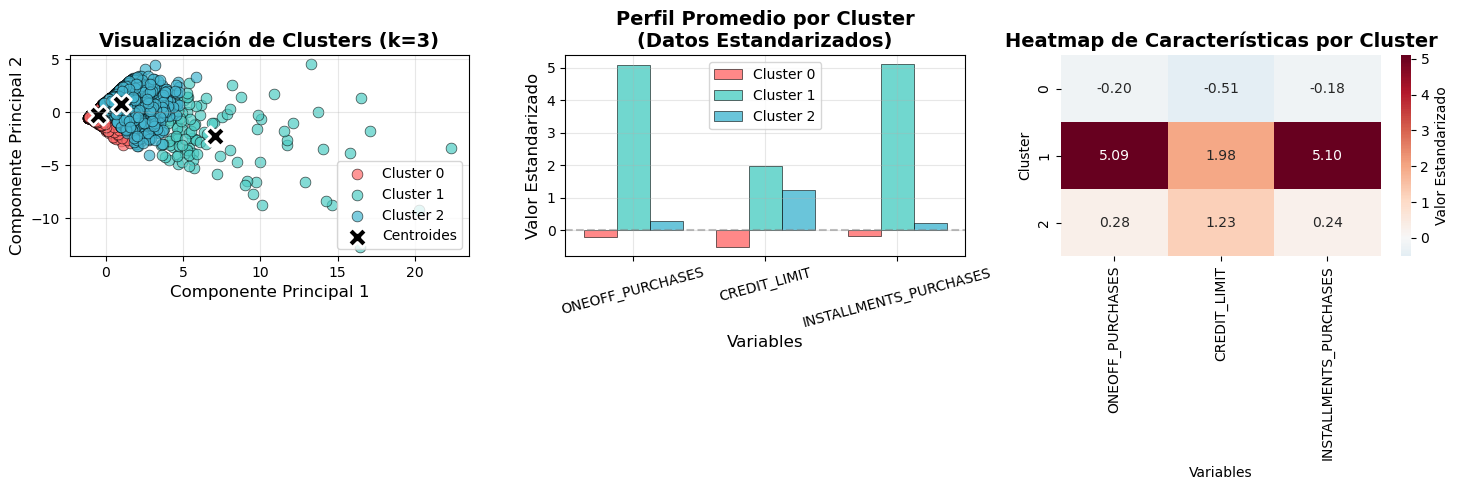

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')
import os

# Cambiar directorio de trabajo
os.chdir('C:/Users/Usuario/Downloads')
df = pd.read_csv('CC_GENERAL.csv')

print("="*50)
print(f"\n📊 Dimensiones del archivo: {df.shape}")
print("="*50)
print(f"Columnas: {df.columns.tolist()}")
print("="*50)
print(f"Info de Columnas: {df.info(5)}")
df.head(5)

# Preparación / Reemplazos / Distribución / Boxplots / Estandarización / 
# a) Verificar duplicados
print("\n" + "=" * 40)
print("a) VERIFICACIÓN DE DUPLICADOS")
print("=" * 40)

duplicados = df.duplicated().sum()
print(f"Número de registros duplicados: {duplicados}")
if duplicados == 0:
    print("No se encontraron registros duplicados.")
else:
    print(f"Se encontraron {duplicados} registros duplicados.")

# b) Detectar valores nulos y reemplazarlos por 0
print("\n" + "=" * 40)
print("b) DETECCIÓN Y TRATAMIENTO DE VALORES NULOS")
print("=" * 40)
# Mostrar valores nulos por columna
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Columnas con valores nulos
print("\nColumnas con valores nulos:")
columnas_con_nulos = df.columns[df.isnull().any()].tolist()
for col in columnas_con_nulos:
    print(f"  - {col}: {df[col].isnull().sum()} valores nulos")

# Reemplazar valores nulos por 0 en las columnas especificadas
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(0)
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(0)

# Verificar que no queden nulos
print("\nValores nulos por columna (después del tratamiento):")
print(df.isnull().sum())

# c) Resumen
# Resumen estadístico
print("\n📊 Resumen estadístico e información de las variables numéricas:")
print(df.describe())
print(df.info())

# Distribución de cada columna numérica
print("\n📈 Distribución de variables numéricas:")

# Configuración de gráficos
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

numeric_columns = df.select_dtypes(include=[np.number]).columns
for i, col in enumerate(numeric_columns):
    if i < len(axes):
        # Histograma
        axes[i].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'Distribución de {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')
        axes[i].grid(True, alpha=0.3)

# Ocultar ejes vacíos
for i in range(len(numeric_columns), len(axes)):
    axes[i].axis('off')

plt.tight_layout()

# Mostrar valores atípicos con boxplots
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    if i < len(axes):
        axes[i].boxplot(df[col].dropna())
        axes[i].set_title(f'Boxplot de {col}')
        axes[i].grid(True, alpha=0.3)

for i in range(len(numeric_columns), len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# d) Estandarización de columnas (StandardScaler)
print("\n" + "=" * 40)
print("d) ESTANDARIZACIÓN DE COLUMNAS")
print("=" * 40)

# Columnas a estandarizar
columnas_a_estandarizar = ['BALANCE', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 
                          'CREDIT_LIMIT', 'MINIMUM_PAYMENTS']

print(f"\nColumnas a estandarizar: {columnas_a_estandarizar}")

# Crear copia para estandarización
df_estandarizado = df.copy()

# Aplicar StandardScaler
scaler = StandardScaler()
df_estandarizado[columnas_a_estandarizar] = scaler.fit_transform(
    df_estandarizado[columnas_a_estandarizar]
)

# Mostrar las primeras filas para comparar lo estadarizado
print("\n🔍 Primeras 5 filas - Datos originales:")
print(df[columnas_a_estandarizar].head())

print("\n🔍 5 filas aleatorias - Datos estandarizados:")
print(df_estandarizado[columnas_a_estandarizar].sample(5))

# Guardar el dataset estandarizado
df_estandarizado.to_csv('CC_GENERAL_C_ESTANDARIZADO.csv', index=False)

# RESULTADOS 
print("\n" + "=" * 40)
print("RESULTADOS ESTADÍSTICOS")
print("=" * 40)

# Verificar la estandarización (media ≈ 0, desviación ≈ 1)
print("\n✅ Verificación de estandarización (media ≈ 0, std ≈ 1):")
for col in columnas_a_estandarizar:
    media = df_estandarizado[col].mean()
    std = df_estandarizado[col].std()
    print(f"  {col}: media = {media:.10f}, std = {std:.10f}")

# Correlaciones entre variables
print("\n📊 Matriz de correlación entre variables originales:")
correlacion = df[columnas_a_estandarizar].corr()
print(correlacion)

# Matriz de correlación visual
plt.figure(figsize=(10, 8))
sns.heatmap(correlacion, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación - Variables Originales')
plt.tight_layout()
plt.show()

# K-MEANS / MÉTODO Y/ GRÁFICO ELBOW / ESTADÍSTICAS / EVALUACIÓN DE CLÚSTERS
df = pd.read_csv('CC_GENERAL_standarizado.csv')

# 1) PREPARACIÓN DE DATOS PARA K-MEANS (USANDO DATOS YA ESTANDARIZADOS)
print("=" * 80)
print("ANÁLISIS DE CLUSTERING CON K-MEANS (DATOS ESTANDARIZADOS)")
print("=" * 80)

# Seleccionar las 3 variables (ya estandarizadas)
variables_kmeans = ['ONEOFF_PURCHASES', 'CREDIT_LIMIT', 'INSTALLMENTS_PURCHASES']
df_kmeans = df[variables_kmeans].copy()

# Verificar que los datos están estandarizados (media ≈ 0, std ≈ 1)
print("\n📊 Verificación de estandarización:")
for col in variables_kmeans:
    media = df_kmeans[col].mean()
    std = df_kmeans[col].std()
    print(f"  {col}: media = {media:.6f}, std = {std:.6f}")
    
    # Si no están estandarizados, aplicar StandardScaler
    if abs(media) > 0.1 or abs(std - 1) > 0.1:
        print(f"  ⚠️ {col} NO está estandarizado correctamente. Aplicando estandarización...")
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler()
        df_kmeans[col] = scaler.fit_transform(df_kmeans[[col]])
    else:
        print(f"  ✅ {col} está correctamente estandarizado")

# Datos para K-Means (ya estandarizados)
df_kmeans_scaled = df_kmeans.values

print(f"\n✅ Datos listos para K-Means")
print(f"Forma del dataset: {df_kmeans_scaled.shape}")

# 2) MÉTODO DEL CODO (ELBOW METHOD)
print("\n" + "=" * 40)
print("MÉTODO DEL CODO - DETERMINACIÓN DE CLUSTERS ÓPTIMOS")
print("=" * 40)

# Calcular inercia para diferentes números de clusters
inercia = []
rango_clusters = range(1, 11)

for k in rango_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_kmeans_scaled)
    inercia.append(kmeans.inertia_)

# Crear el gráfico del codo
plt.figure(figsize=(14, 6))

# Gráfico principal - Método del codo
plt.subplot(1, 2, 1)
plt.plot(rango_clusters, inercia, 'bo-', linewidth=2, markersize=8, 
         markerfacecolor='blue', markeredgecolor='darkblue')
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inercia (Suma de distancias cuadradas)', fontsize=12)
plt.title('Método del Codo para K-Means', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(rango_clusters)

# Añadir anotaciones con los valores
for i, (k, iner) in enumerate(zip(rango_clusters, inercia)):
    plt.annotate(f'{iner:.0f}', (k, iner), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)

# Gráfico de cambios porcentuales
plt.subplot(1, 2, 2)
cambios = [(inercia[i-1] - inercia[i]) / inercia[i-1] * 100 for i in range(1, len(inercia))]
plt.plot(rango_clusters[1:], cambios, 'ro-', linewidth=2, markersize=8,
         markerfacecolor='red', markeredgecolor='darkred')
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Cambio Porcentual en Inercia (%)', fontsize=12)
plt.title('Cambio Porcentual de Inercia', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(rango_clusters[1:])

for i, (k, cambio) in enumerate(zip(rango_clusters[1:], cambios)):
    plt.annotate(f'{cambio:.1f}%', (k, cambio), textcoords="offset points", 
                xytext=(0,10), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('elbow_plot_kmeans.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico del método del codo guardado como 'elbow_plot_kmeans.png'")
plt.show()

# Análisis del punto de codo
print("\n📊 Análisis del método del codo:")
print("-" * 50)
print("Inercia por número de clusters:")
for k, iner in zip(rango_clusters, inercia):
    print(f"  k={k}: {iner:.2f}")

print("\nCambios porcentuales:")
for i, (k, cambio) in enumerate(zip(rango_clusters[1:], cambios)):
    print(f"  k={k-1} → k={k}: {cambio:.2f}% de reducción")

# Determinar el punto de codo
cambio_promedio = np.mean(cambios)
codo_punto = None
for i, cambio in enumerate(cambios):
    if cambio < cambio_promedio * 0.5:
        codo_punto = i + 2
        break

if codo_punto:
    print(f"\n🎯 Punto de codo identificado: k={codo_punto}")
    print(f"   (El cambio porcentual cae por debajo de {cambio_promedio*0.5:.1f}%)")
else:
    print("\n🎯 Punto de codo sugerido: k=3 (según la gráfica)")

# 3) APLICAR K-MEANS CON NÚMERO ÓPTIMO DE CLUSTERS
print("\n" + "=" * 40)
print("APLICACIÓN DE K-MEANS")
print("=" * 40)

# Usar k=3 como número óptimo (ajustable según el codo)
n_clusters_optimo = 3
print(f"\n🎯 Usando k={n_clusters_optimo} clusters (según análisis del método del codo)")

# Aplicar K-Means
kmeans_optimo = KMeans(n_clusters=n_clusters_optimo, random_state=42, n_init=10)
clusters = kmeans_optimo.fit_predict(df_kmeans_scaled)

# Añadir los clusters al dataframe original
df['Cluster'] = clusters

print(f"\n✅ Clustering completado con {n_clusters_optimo} clusters")

# B) CONTEO DE CLUSTERS ACTUALES
print("\n" + "=" * 40)
print("B) CONTEO DE CLUSTERS ACTUALES")
print("=" * 40)
print(f"\nDistribución de clusters:")
cluster_counts = df['Cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    print(f"  Cluster {cluster}: {count} clientes ({count/len(df)*100:.1f}%)")

# 4) VISUALIZACIÓN DE RESULTADOS
print("\n" + "=" * 40)
print("VISUALIZACIÓN DE CLUSTERS")
print("=" * 40)

# Reducir dimensiones con PCA para visualización 2D
pca = PCA(n_components=2)
df_kmeans_pca = pca.fit_transform(df_kmeans_scaled)

# Crear dataframe para visualización
df_viz = pd.DataFrame({
    'PCA1': df_kmeans_pca[:, 0],
    'PCA2': df_kmeans_pca[:, 1],
    'Cluster': clusters
})

# Gráfico de clusters en 2D
plt.figure(figsize=(15, 5))

# Scatter plot de los clusters
plt.subplot(1, 3, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
for cluster in range(n_clusters_optimo):
    mask = df_viz['Cluster'] == cluster
    plt.scatter(df_viz.loc[mask, 'PCA1'], df_viz.loc[mask, 'PCA2'], 
               c=colors[cluster % len(colors)], label=f'Cluster {cluster}', 
               alpha=0.7, s=60, edgecolors='black', linewidth=0.5)

# Centros de clusters en espacio PCA
centroids_pca = pca.transform(kmeans_optimo.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
           c='black', marker='X', s=200, label='Centroides', 
           edgecolors='white', linewidth=2)

plt.xlabel('Componente Principal 1', fontsize=12)
plt.ylabel('Componente Principal 2', fontsize=12)
plt.title(f'Visualización de Clusters (k={n_clusters_optimo})', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico de perfiles por cluster (en espacio original estandarizado)
plt.subplot(1, 3, 2)
cluster_means = df.groupby('Cluster')[variables_kmeans].mean()

# Gráfico de barras agrupadas
x = np.arange(len(variables_kmeans))
width = 0.25

for i, cluster in enumerate(range(n_clusters_optimo)):
    offset = (i - (n_clusters_optimo-1)/2) * width
    plt.bar(x + offset, cluster_means.iloc[i], width, 
            label=f'Cluster {i}', alpha=0.8,
            color=colors[i % len(colors)], edgecolor='black', linewidth=0.5)

plt.xlabel('Variables', fontsize=12)
plt.ylabel('Valor Estandarizado', fontsize=12)
plt.title('Perfil Promedio por Cluster\n(Datos Estandarizados)', fontsize=14, fontweight='bold')
plt.xticks(x, variables_kmeans, rotation=15)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)

# Heatmap de características por cluster
plt.subplot(1, 3, 3)
# Crear un heatmap de las medias por cluster
cluster_heatmap = df.groupby('Cluster')[variables_kmeans].mean()
sns.heatmap(cluster_heatmap, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, cbar_kws={'label': 'Valor Estandarizado'})
plt.title('Heatmap de Características por Cluster', fontsize=14, fontweight='bold')
plt.ylabel('Cluster')
plt.xlabel('Variables')

plt.tight_layout()
plt.savefig('clusters_visualization.png', dpi=300, bbox_inches='tight')
plt.show()


A) BAR PLOTS PARA CLUSTER 1 (MUY ALTO EN TODAS LAS VARIABLES)

Cluster 1 tiene 112 clientes
✅ Gráfico del Cluster 1 guardado como 'cluster_1_analysis.png'


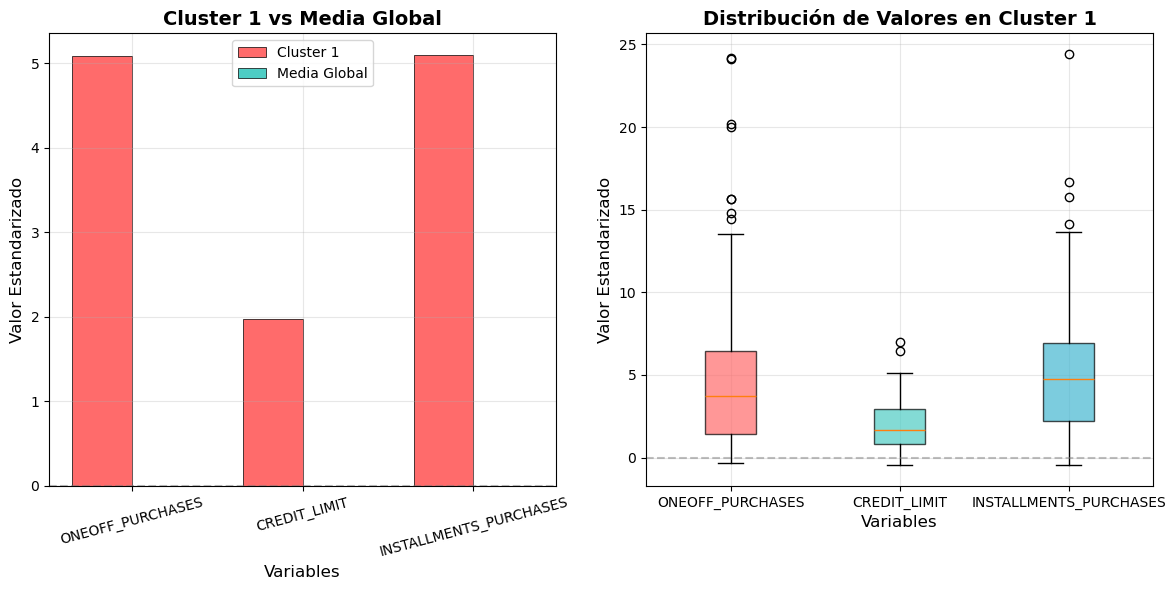


📊 Estadísticas del Cluster 1:
  ONEOFF_PURCHASES:
    Media: 5.090
    Desviación: 5.139
    Mínimo: -0.357
    Máximo: 24.201
  CREDIT_LIMIT:
    Media: 1.979
    Desviación: 1.420
    Mínimo: -0.466
    Máximo: 7.010
  INSTALLMENTS_PURCHASES:
    Media: 5.101
    Desviación: 4.348
    Mínimo: -0.455
    Máximo: 24.427

ANÁLISIS DETALLADO DE CLUSTERS

📊 Estadísticas por cluster (datos estandarizados):

CLUSTER 0 - 6378 clientes

Variables analizadas (promedio en escala estandarizada):
  ONEOFF_PURCHASES:
    Media: -0.199
    Desviación: 0.332
  CREDIT_LIMIT:
    Media: -0.509
    Desviación: 0.415
  INSTALLMENTS_PURCHASES:
    Media: -0.181
    Desviación: 0.462

Características distintivas:
  ➖ ONEOFF_PURCHASES: PROMEDIO (-0.20 desviaciones de la media)
  ❌ CREDIT_LIMIT: MUY BAJO (-0.51 desviaciones bajo la media)
  ➖ INSTALLMENTS_PURCHASES: PROMEDIO (-0.18 desviaciones de la media)

CLUSTER 1 - 112 clientes

Variables analizadas (promedio en escala estandarizada):
  ONEOFF_PURCHAS

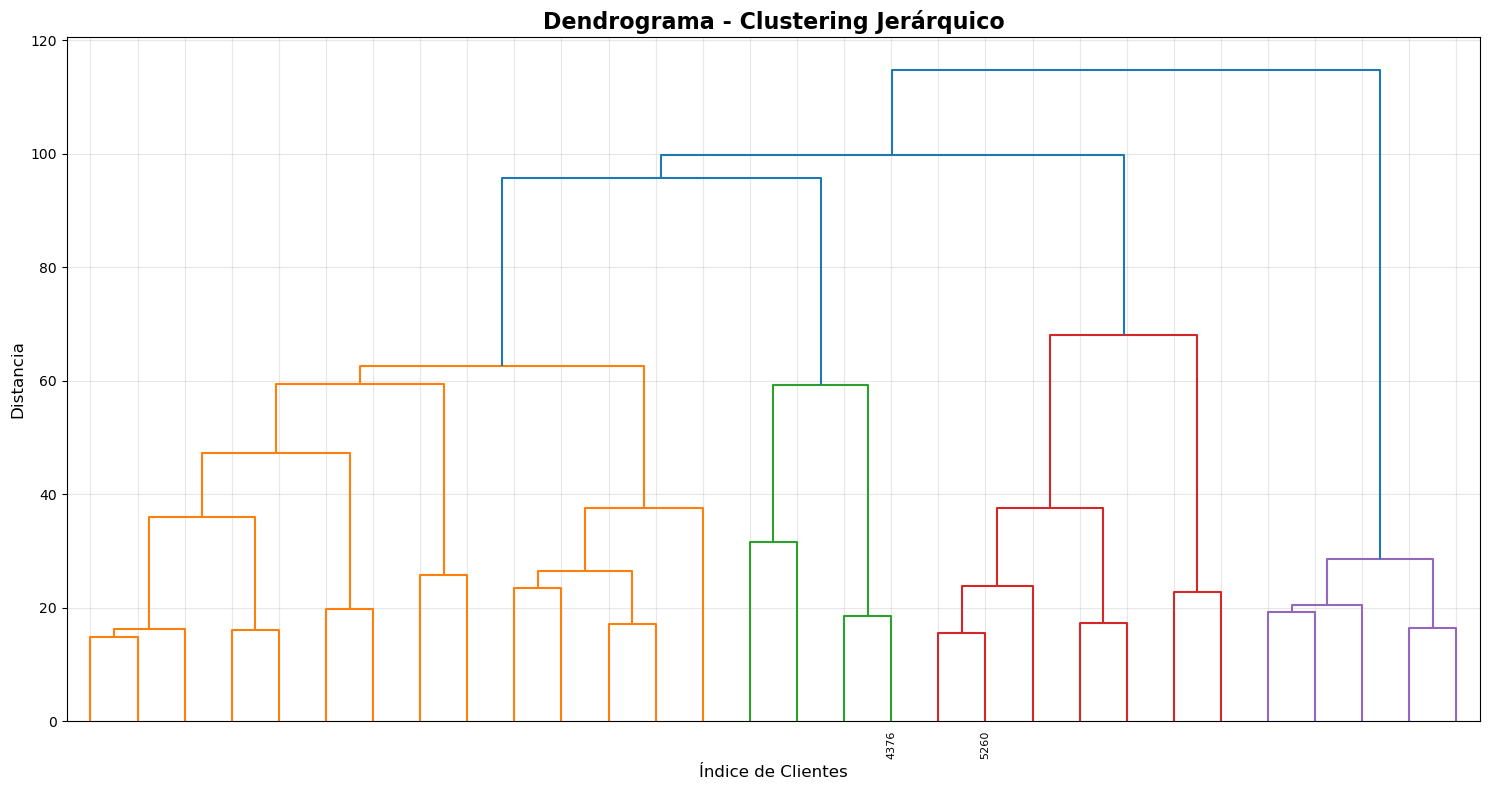


🔍 Aplicando clustering jerárquico con k=3 clusters...

Distribución de clusters jerárquicos:
  Cluster 0: 3555 clientes (39.7%)
  Cluster 1: 5324 clientes (59.5%)
  Cluster 2: 71 clientes (0.8%)

D) SILHOUETTE SCORE PARA CLUSTERING JERÁRQUICO

📊 Silhouette Score para Clustering Jerárquico:
  • Silhouette Score: 0.386

📝 Interpretación:
  ⚠️ Silhouette Score entre 0.3 y 0.5: Separación aceptable

📊 Comparación de modelos:
  • K-Means Silhouette Score: 0.487
  • Hierarchical Silhouette Score: 0.386
  ✅ K-Means tiene mejor rendimiento que Hierarchical

E) INTERPRETACIÓN DE CLUSTERS GENERADOS POR CLUSTERING JERÁRQUICO

📊 Perfil de los clusters jerárquicos:
--------------------------------------------------

CLUSTER JERÁRQUICO 0: 3555 clientes (39.7% del total)

Variables analizadas (promedio en escala estandarizada):
  ONEOFF_PURCHASES: 0.248
  INSTALLMENTS_PURCHASES: 0.268
  CREDIT_LIMIT: 0.831
  MINIMUM_PAYMENTS: 0.239

Características distintivas:
  📈 ONEOFF_PURCHASES: ALTO (0.25 desvi

In [2]:
# BAR PLOTS ESPECÍFICOS PARA CLUSTER 1
print("\n" + "=" * 40)
print("A) BAR PLOTS PARA CLUSTER 1 (MUY ALTO EN TODAS LAS VARIABLES)")
print("=" * 40)

# Filtrar datos del cluster 1
cluster_1_data = df[df['Cluster'] == 1]
print(f"\nCluster 1 tiene {len(cluster_1_data)} clientes")

# Crear gráfico de barras para el cluster 1
plt.figure(figsize=(12, 6))

# Subplot 1: Comparación de medias del cluster 1 vs media global
plt.subplot(1, 2, 1)
cluster_1_means = cluster_1_data[variables_kmeans].mean()
global_means = df[variables_kmeans].mean()

x = np.arange(len(variables_kmeans))
width = 0.35

bars1 = plt.bar(x - width/2, cluster_1_means, width, label='Cluster 1', 
                color='#FF6B6B', edgecolor='black', linewidth=0.5)
bars2 = plt.bar(x + width/2, global_means, width, label='Media Global', 
                color='#4ECDC4', edgecolor='black', linewidth=0.5)

plt.xlabel('Variables', fontsize=12)
plt.ylabel('Valor Estandarizado', fontsize=12)
plt.title('Cluster 1 vs Media Global', fontsize=14, fontweight='bold')
plt.xticks(x, variables_kmeans, rotation=15)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Distribución de valores en el cluster 1
plt.subplot(1, 2, 2)
# Crear un boxplot de la distribución
data_to_plot = [cluster_1_data[var] for var in variables_kmeans]
bp = plt.boxplot(data_to_plot, labels=variables_kmeans, patch_artist=True)

# Colorear los boxplots
for patch, color in zip(bp['boxes'], ['#FF6B6B', '#4ECDC4', '#45B7D1']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.xlabel('Variables', fontsize=12)
plt.ylabel('Valor Estandarizado', fontsize=12)
plt.title('Distribución de Valores en Cluster 1', fontsize=14, fontweight='bold')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cluster_1_analysis.png', dpi=300, bbox_inches='tight')
print("✅ Gráfico del Cluster 1 guardado como 'cluster_1_analysis.png'")
plt.show()

# Mostrar estadísticas del cluster 1
print("\n📊 Estadísticas del Cluster 1:")
for var in variables_kmeans:
    mean_val = cluster_1_data[var].mean()
    std_val = cluster_1_data[var].std()
    min_val = cluster_1_data[var].min()
    max_val = cluster_1_data[var].max()
    print(f"  {var}:")
    print(f"    Media: {mean_val:.3f}")
    print(f"    Desviación: {std_val:.3f}")
    print(f"    Mínimo: {min_val:.3f}")
    print(f"    Máximo: {max_val:.3f}")

# 5) ANÁLISIS DETALLADO DE CLUSTERS
print("\n" + "=" * 40)
print("ANÁLISIS DETALLADO DE CLUSTERS")
print("=" * 40)

# Estadísticas por cluster
print("\n📊 Estadísticas por cluster (datos estandarizados):")
for cluster in sorted(df['Cluster'].unique()):
    print(f"\n{'='*30}")
    print(f"CLUSTER {cluster} - {len(df[df['Cluster']==cluster])} clientes")
    print(f"{'='*30}")
    
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\nVariables analizadas (promedio en escala estandarizada):")
    for var in variables_kmeans:
        mean_val = cluster_data[var].mean()
        std_val = cluster_data[var].std()
        print(f"  {var}:")
        print(f"    Media: {mean_val:.3f}")
        print(f"    Desviación: {std_val:.3f}")
    
    # Características distintivas en escala estandarizada
    print(f"\nCaracterísticas distintivas:")
    for var in variables_kmeans:
        cluster_mean = cluster_data[var].mean()
        # En escala estandarizada, valores > 0.5 indican alto, < -0.5 indican bajo
        if cluster_mean > 0.5:
            print(f"  ✅ {var}: MUY ALTO ({cluster_mean:.2f} desviaciones sobre la media)")
        elif cluster_mean > 0.2:
            print(f"  📈 {var}: ALTO ({cluster_mean:.2f} desviaciones sobre la media)")
        elif cluster_mean < -0.5:
            print(f"  ❌ {var}: MUY BAJO ({cluster_mean:.2f} desviaciones bajo la media)")
        elif cluster_mean < -0.2:
            print(f"  📉 {var}: BAJO ({cluster_mean:.2f} desviaciones bajo la media)")
        else:
            print(f"  ➖ {var}: PROMEDIO ({cluster_mean:.2f} desviaciones de la media)")

# 6) EVALUACIÓN DE CALIDAD DEL CLUSTERING
print("\n" + "=" * 40)
print("EVALUACIÓN DE CALIDAD DEL CLUSTERING")
print("=" * 40)

# Métricas de evaluación
silhouette = silhouette_score(df_kmeans_scaled, clusters)
calinski = calinski_harabasz_score(df_kmeans_scaled, clusters)
davies = davies_bouldin_score(df_kmeans_scaled, clusters)

print(f"\n📊 Métricas de calidad del clustering:")
print(f"  • Silhouette Score: {silhouette:.3f} (más cercano a 1 = mejor)")
print(f"  • Calinski-Harabasz: {calinski:.1f} (más alto = mejor)")
print(f"  • Davies-Bouldin: {davies:.3f} (más bajo = mejor)")

# Interpretación
print(f"\n📝 Interpretación:")
if silhouette > 0.5:
    print("  ✅ Silhouette Score > 0.5: Excelente separación entre clusters")
elif silhouette > 0.3:
    print("  ⚠️ Silhouette Score entre 0.3 y 0.5: Separación aceptable")
else:
    print("  ❌ Silhouette Score < 0.3: Separación débil, considerar otros k")


# C) CLUSTERING JERÁRQUICO CON DENDOGRAMA
print("\n" + "=" * 40)
print("C) CLUSTERING JERÁRQUICO - DENDOGRAMA")
print("=" * 40)

# Preparar datos para clustering jerárquico
variables_jerarquico = ['ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CREDIT_LIMIT', 'MINIMUM_PAYMENTS']
df_jerarquico = df[variables_jerarquico].copy()

# Verificar que los datos están estandarizados
print("\n📊 Verificación de estandarización para clustering jerárquico:")
for col in variables_jerarquico:
    media = df_jerarquico[col].mean()
    std = df_jerarquico[col].std()
    print(f"  {col}: media = {media:.6f}, std = {std:.6f}")
    
    # Si no están estandarizados, aplicar StandardScaler
    if abs(media) > 0.1 or abs(std - 1) > 0.1:
        print(f"  ⚠️ {col} NO está estandarizado correctamente. Aplicando estandarización...")
        scaler = StandardScaler()
        df_jerarquico[col] = scaler.fit_transform(df_jerarquico[[col]])
    else:
        print(f"  ✅ {col} está correctamente estandarizado")

# Datos para clustering jerárquico
df_jerarquico_scaled = df_jerarquico.values

# Generar dendrograma
plt.figure(figsize=(15, 8))
linked = linkage(df_jerarquico_scaled, method='ward')
dendrogram(linked, 
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=False,
           leaf_rotation=90,
           leaf_font_size=8,
           truncate_mode='lastp',
           p=30)  # Mostrar solo 30 hojas para mejor visualización

plt.title('Dendrograma - Clustering Jerárquico', fontsize=16, fontweight='bold')
plt.xlabel('Índice de Clientes', fontsize=12)
plt.ylabel('Distancia', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('dendrograma_clustering.png', dpi=300, bbox_inches='tight')
plt.show()

# Aplicar clustering jerárquico con k=3 clusters
print("\n🔍 Aplicando clustering jerárquico con k=3 clusters...")
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters_hierarchical = hierarchical.fit_predict(df_jerarquico_scaled)

# Añadir clusters jerárquicos al dataframe
df['Cluster_Hierarchical'] = clusters_hierarchical

# Mostrar distribución de clusters jerárquicos
print("\nDistribución de clusters jerárquicos:")
hierarchical_counts = df['Cluster_Hierarchical'].value_counts().sort_index()
for cluster, count in hierarchical_counts.items():
    print(f"  Cluster {cluster}: {count} clientes ({count/len(df)*100:.1f}%)")

print("\n" + "=" * 40)
print("D) SILHOUETTE SCORE PARA CLUSTERING JERÁRQUICO")
print("=" * 40)
# Calcular silhouette score para el modelo jerárquico
silhouette_hierarchical = silhouette_score(df_jerarquico_scaled, clusters_hierarchical)
print(f"\n📊 Silhouette Score para Clustering Jerárquico:")
print(f"  • Silhouette Score: {silhouette_hierarchical:.3f}")

# Interpretación
print(f"\n📝 Interpretación:")
if silhouette_hierarchical > 0.5:
    print("  ✅ Silhouette Score > 0.5: Excelente separación entre clusters")
elif silhouette_hierarchical > 0.3:
    print("  ⚠️ Silhouette Score entre 0.3 y 0.5: Separación aceptable")
else:
    print("  ❌ Silhouette Score < 0.3: Separación débil, considerar otros parámetros")

# Comparación de modelos
print(f"\n📊 Comparación de modelos:")
print(f"  • K-Means Silhouette Score: {silhouette:.3f}")
print(f"  • Hierarchical Silhouette Score: {silhouette_hierarchical:.3f}")
if silhouette > silhouette_hierarchical:
    print("  ✅ K-Means tiene mejor rendimiento que Hierarchical")
else:
    print("  ✅ Hierarchical tiene mejor rendimiento que K-Means")

# E) INTERPRETACIÓN FINAL DE CLUSTERS JERÁRQUICOS
print("\n" + "=" * 80)
print("E) INTERPRETACIÓN DE CLUSTERS GENERADOS POR CLUSTERING JERÁRQUICO")
print("=" * 80)

print("\n📊 Perfil de los clusters jerárquicos:")
print("-" * 50)

# Calcular medias por cluster jerárquico
hierarchical_means = df.groupby('Cluster_Hierarchical')[variables_jerarquico].mean()

for cluster in sorted(df['Cluster_Hierarchical'].unique()):
    cluster_data = df[df['Cluster_Hierarchical'] == cluster]
    n_clientes = len(cluster_data)
    pct = (n_clientes / len(df)) * 100
    
    print(f"\n{'='*40}")
    print(f"CLUSTER JERÁRQUICO {cluster}: {n_clientes} clientes ({pct:.1f}% del total)")
    print(f"{'='*40}")
    
    print(f"\nVariables analizadas (promedio en escala estandarizada):")
    for var in variables_jerarquico:
        mean_val = cluster_data[var].mean()
        print(f"  {var}: {mean_val:.3f}")
    
    print(f"\nCaracterísticas distintivas:")
    for var in variables_jerarquico:
        cluster_mean = cluster_data[var].mean()
        if cluster_mean > 0.5:
            print(f"  ✅ {var}: MUY ALTO ({cluster_mean:.2f} desviaciones sobre la media)")
        elif cluster_mean > 0.2:
            print(f"  📈 {var}: ALTO ({cluster_mean:.2f} desviaciones sobre la media)")
        elif cluster_mean < -0.5:
            print(f"  ❌ {var}: MUY BAJO ({cluster_mean:.2f} desviaciones bajo la media)")
        elif cluster_mean < -0.2:
            print(f"  📉 {var}: BAJO ({cluster_mean:.2f} desviaciones bajo la media)")
        else:
            print(f"  ➖ {var}: PROMEDIO ({cluster_mean:.2f} desviaciones de la media)")
    
    # Interpretación del cluster
    print(f"\n📝 Interpretación del Cluster {cluster}:")
    # Determinar perfil basado en las variables
    oneoff = cluster_data['ONEOFF_PURCHASES'].mean()
    instal = cluster_data['INSTALLMENTS_PURCHASES'].mean()
    credit = cluster_data['CREDIT_LIMIT'].mean()
    min_pay = cluster_data['MINIMUM_PAYMENTS'].mean()
    
    if oneoff > 0.3 and credit > 0.3 and instal > 0.3:
        print("  🏆 CLIENTE PREMIUM: Alto en todas las categorías - Alto valor")
    elif oneoff > 0.3 and credit > 0.3 and instal < 0.3:
        print("  🛍️ CLIENTE DE COMPRAS ÚNICAS: Alto límite y compras únicas - Compras contado")
    elif oneoff < 0.3 and credit > 0.3 and instal > 0.3:
        print("  💳 CLIENTE DE FINANCIAMIENTO: Buen límite, prefiere compras a plazos")
    elif oneoff < -0.3 and credit < -0.3 and instal < -0.3:
        print("  📉 CLIENTE DE BAJO CONSUMO: Bajo límite y pocas compras - Potencial upselling")
    else:
        print("  📊 CLIENTE MIXTO: Perfil equilibrado con características variadas")
    
    # Recomendaciones
    print(f"\n💡 Recomendaciones para Cluster {cluster}:")
    if oneoff > 0.3 and credit > 0.3:
        print("  • Ofrecer tarjetas premium con mayores beneficios")
        print("  • Programas de lealtad y cashback")
    if instal > 0.3:
        print("  • Promociones de financiamiento y plazos especiales")
    if credit < -0.3:
        print("  • Campañas para aumento de límite de crédito")
        print("  • Educación financiera y uso de tarjeta")
    if min_pay < -0.3:
        print("  • Campañas de pago mínimo y gestión de deuda")